In [1]:
import numpy as np

In [2]:
# read H2
dim = 4
nR = 10
Rs = np.zeros((nR),dtype=float)
E_qzmc_H2 = np.zeros((nR,dim),dtype=float)
with open('./H2/lagos/H2.qzmc.energies','r') as file_:
    iR = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        Rs[iR] = float(ls[0])
        for k in range(dim):
            E_qzmc_H2[iR,k] = float(ls[k+1])
        iR += 1

nR_fine = 100
Rs_fine = np.zeros((nR_fine),dtype=float)
E_fine_H2 = np.zeros((nR_fine,dim),dtype=float)

with open('./H2/lagos/H2.fine.energies','r') as file_:
    iR = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        Rs_fine[iR] = float(ls[0])
        for k in range(dim):
            E_fine_H2[iR,k] = float(ls[k+1])
        iR += 1
        if (iR>=nR_fine):
            break
#print(Rs,E_qzmc_H2)

In [3]:
# read dimer
dim = 4
nU = 11
Us = np.zeros((nU),dtype=float)
E_qzmc_dimer = np.zeros((nU,dim),dtype=float)
with open('./dimer/perth/dimer.qzmc.energies','r') as file_:
    iU = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        Us[iU] = float(ls[0])
        for k in range(dim):
            E_qzmc_dimer[iU,k] = float(ls[k+1])
        iU += 1

E_direct_dimer = np.zeros((nU,dim),dtype=float)
with open('./dimer/perth/dimer.qzmc.energies.direct','r') as file_:
    iU = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        for k in range(dim):
            E_direct_dimer[iU,k] = float(ls[k+1])
        iU += 1

E_exact_dimer = np.zeros((nU,dim),dtype=float)
with open('./dimer/qasm/dimer.exact.energies','r') as file_:
    iU = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        for k in range(dim):
            E_exact_dimer[iU,k] = float(ls[k+1])
        iU += 1

norms_qzmc_dimer = np.zeros((nU,dim), dtype=float)
with open('./dimer/perth/dimer.qzmc.norms','r') as file_:
    iU = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        for k in range(dim):
            norms_qzmc_dimer[iU,k] = float(ls[k+1])
        iU += 1

norms_qasm_dimer = np.zeros((nU,dim), dtype=float)
with open('./dimer/qasm/dimer.qzmc.norms','r') as file_:
    iU = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        for k in range(dim):
            norms_qasm_dimer[iU,k] = float(ls[k+1])
        iU += 1

norms_exact_dimer = np.zeros((nU,dim), dtype=float)
with open('./dimer/qasm/dimer.exact.norms','r') as file_:
    iU = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        for k in range(dim):
            norms_exact_dimer[iU,k] = float(ls[k+1])
        iU += 1

nU_fine = 101
Us_fine = np.zeros((nU_fine),dtype=float)
E_fine_dimer = np.zeros((nU_fine,dim),dtype=float)
with open('./dimer/perth/dimer.fine.energies','r') as file_:
    iU = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        Us_fine[iU] = float(ls[0])
        for k in range(dim):
            E_fine_dimer[iU,k] = float(ls[k+1])
        iU += 1
#print(Us_fine,E_fine_dimer)

In [4]:
# read green
nom = 121
nk  = 2
oml = np.zeros((nom),dtype=float)

A_exact = np.zeros((nom,nk),dtype=float)
with open('./dimer/perth/green/A.exact','r') as file_:
    iom = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        oml[iom] = float(ls[0])
        for k in range(nk):
            A_exact[iom,k] = float(ls[k+1])
        iom += 1

A_qzmc = np.zeros((nom,nk),dtype=float)
with open('./dimer/perth/green/A.qzmc','r') as file_:
    iom = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        for k in range(nk):
            A_qzmc[iom,k] = float(ls[k+1])
        iom += 1


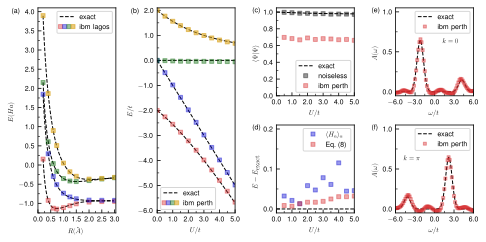

In [5]:
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf','svg')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.legend_handler import HandlerTuple
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size"  : 7
})

cm    = 1.0/2.54
width_col = 8.6*cm
width = width_col*2 
height = width_col
plt.figure(figsize=(width,height),dpi=600)

marker_style_ref = dict(marker='',linestyle='dashed',linewidth=1.0, color='black')
marker_style_1  = dict(marker='s', linestyle='none', color='tab:red', alpha=0.4,  fillstyle='full')
marker_style_2  = dict(marker='s', linestyle='none', color='mediumblue', alpha=0.4,  fillstyle='full')
marker_style_3  = dict(marker='s', linestyle='none', color='black', alpha=0.4,  fillstyle='full')
marker_style_4  = dict(marker='s', linestyle='none', color='darkgreen', alpha=0.4,  fillstyle='full')
marker_style_5  = dict(marker='s', linestyle='none', color='goldenrod', alpha=0.6,  fillstyle='full')


axes = []
ax = plt.subplot2grid((2,4),(0,0),rowspan=2,colspan=1)
axes.append(ax)
ax = plt.subplot2grid((2,4),(0,1),rowspan=2,colspan=1)
axes.append(ax)
ax = plt.subplot2grid((2,4),(0,2))
axes.append(ax)
ax = plt.subplot2grid((2,4),(1,2))
axes.append(ax)
ax = plt.subplot2grid((2,4),(0,3))
axes.append(ax)
ax = plt.subplot2grid((2,4),(1,3))
axes.append(ax)

# (a) H2

axis = axes[0]

y_min    = -1.25
y_max    =  4.1
#
x_min    =  0
x_max    =  3.05

axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
#axes[0].text(-0.25,0.98,'(a)',transform=axes[0].transAxes)
axis.text(-0.34,0.975,r'(a)',transform=axis.transAxes)
#axes[0].text(0.5,-0.2,r'$R(\AA)$',transform=axes[0].transAxes)
axis.set_xlabel(r'$R(\AA)$')
#axes[0].text(-0.25,0.5,r'$E(Ha)$',transform=axes[0].transAxes)
axis.set_ylabel(r'$E(Ha)$')
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
axis.xaxis.set_major_formatter('{x:0.1f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))

axis.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
axis.yaxis.set_major_formatter('{x:0.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))

# plot

#axis.plot(Rs_fine,E_fine_H2[:,0], label='exact', **marker_style_ref)
#axis.plot(Rs,E_qzmc_H2[:,0], label ='ibm_lagos', markersize=4, **marker_style_1)
#
#axis.plot(Rs_fine,E_fine_H2[:,1:], label='', **marker_style_ref)
#axis.plot(Rs,E_qzmc_H2[:,1:], label ='', markersize=4, **marker_style_1)

exact, = axis.plot(Rs_fine,E_fine_H2[:,0], label='', **marker_style_ref)
axis.plot(Rs_fine,E_fine_H2[:,1:], label='', **marker_style_ref)

e0, = axis.plot(Rs,E_qzmc_H2[:,0], label ='', markersize=4, **marker_style_1)
e1, = axis.plot(Rs,E_qzmc_H2[:,1], label ='', markersize=4, **marker_style_2)
e2, = axis.plot(Rs,E_qzmc_H2[:,2], label ='', markersize=4, **marker_style_4)
e3, = axis.plot(Rs,E_qzmc_H2[:,3], label ='', markersize=4, **marker_style_5)


#axis.plot(-1,-1, label='ibm_lagos',markersize=4, **marker_style_3)

axis.legend([exact, (e0,e1,e2,e3)], ['exact', 'ibm_lagos'], numpoints=1,
    handler_map={tuple: HandlerTuple(ndivide=None)},
            loc='upper right')

# (b) dimer

axis = axes[1]

y_min    =  -6.1
y_max    =  2.1
#
x_min    =  0
x_max    =  5
#
axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
#axes[1].text(-0.25,0.98,'(b)',transform=axes[1].transAxes)
axis.text(-0.34,0.975,r'(b)',transform=axis.transAxes)
axis.set_xlabel(r'$U/t$')
axis.set_ylabel(r'$E/t$')
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(1))
axis.xaxis.set_major_formatter('{x:0.1f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))

axis.yaxis.set_major_locator(ticker.MultipleLocator(1))
axis.yaxis.set_major_formatter('{x:0.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

exact, = axis.plot(Us_fine,E_fine_dimer[:,0], label='', **marker_style_ref)
axis.plot(Us_fine,E_fine_dimer[:,1:], label='', **marker_style_ref)
#axis.plot(Us,E_qzmc_dimer[:,0], label ='ibm_perth', markersize=4, **marker_style_1)

#axis.plot(Us_fine,E_fine_dimer[:,1:], label='', **marker_style_ref)
#axis.plot(Us,E_qzmc_dimer[:,1:], label ='', markersize=4, **marker_style_1)

axis.plot(Us,E_qzmc_dimer[:,0], label ='', markersize=4, **marker_style_1)
axis.plot(Us,E_qzmc_dimer[:,1], label ='', markersize=4, **marker_style_2)
axis.plot(Us,E_qzmc_dimer[:,2], label ='', markersize=4, **marker_style_4)
axis.plot(Us,E_qzmc_dimer[:,3], label ='', markersize=4, **marker_style_5)


axis.legend([exact, (e0,e1,e2,e3)], ['exact', 'ibm_perth'], numpoints=1,
    handler_map={tuple: HandlerTuple(ndivide=None)},
            loc='lower left')


# (c) norms 

axis = axes[2]

y_min    = 0.0
y_max    = 1.05

x_min    =  0
x_max    =  5

axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.31,0.95,r'(c)',transform=axis.transAxes)
axis.set_xlabel(r'$U/t$')
axis.set_ylabel(r'$\langle\Psi|\Psi\rangle$')
#axis.text(0.5,-0.2,r'$U/t$',transform=axis.transAxes)
#axis.text(-0.28,0.5,r'$||\Psi||^2$',transform=axis.transAxes)
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(1))
axis.xaxis.set_major_formatter('{x:0.1f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))

axis.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axis.yaxis.set_major_formatter('{x:0.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

# plot
axis.plot(Us,norms_exact_dimer[:,0], label='exact', **marker_style_ref)

axis.plot(Us[1:],norms_qasm_dimer[1:,0], label ='noiseless', markersize=4, **marker_style_3)

axis.plot(Us[1:],norms_qzmc_dimer[1:,0], label ='ibm_perth', markersize=4, **marker_style_1)


axis.legend(loc='lower right')

# (d) E vs dE 

axis = axes[3]

y_min    = -0.01
y_max    = 0.21

x_min    =  0
x_max    =  5

axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.31,0.95,r'(d)',transform=axis.transAxes)
axis.set_xlabel(r'$U/t$')
axis.set_ylabel(r'$E-E_{\textrm{exact}}$')
#axis.text(0.5,-0.2,r'$U/t$',transform=axis.transAxes)
#axis.text(-0.28,0.5,r'$E-E_{\textrm{exact}}$',transform=axis.transAxes)
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(1))
axis.xaxis.set_major_formatter('{x:0.1f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))

axis.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
axis.yaxis.set_major_formatter('{x:0.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))

# plot
axis.axhline(y=0, label='', **marker_style_ref)

axis.plot(Us[1:],E_direct_dimer[1:,0]-E_exact_dimer[1:,0], label = r'$\langle{H_\alpha}\rangle_\alpha$', markersize=4, **marker_style_2)

axis.plot(Us[1:],E_qzmc_dimer[1:,0]-E_exact_dimer[1:,0], label =r'Eq.~(8)', markersize=4, **marker_style_1)



axis.legend(loc='upper right')

# (e) Ak(k=0)

axis = axes[4]

y_min    =  -0.05
y_max    =  1.05
#
x_min    =  -6
x_max    =  6

axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.31,0.95,r'(e)',transform=axis.transAxes)
axis.set_xlabel(r'$\omega/t$')
axis.set_ylabel(r'$A(\omega)$')
#axis.text(0.5,-0.2,r'$\omega/t$',transform=axis.transAxes)
#axis.text(-0.28,0.5,r'$A(\omega)$',transform=axis.transAxes)
axis.text(0.60,0.6,r'$k=0$',transform=axis.transAxes)
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(3))
axis.xaxis.set_major_formatter('{x:0.1f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(1.5))

axis.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
axis.yaxis.set_major_formatter('{x:0.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))

# plot
axis.plot(oml,A_exact[:,0], label='exact', **marker_style_ref)

axis.plot(oml,A_qzmc[:,0], label ='ibm_perth', markersize=3, **marker_style_1)

axis.legend(loc='upper right')

# (f) Ak(k=\pi)

axis = axes[5]

y_min    =  -0.05
y_max    =  1.05
#
x_min    =  -6
x_max    =  6

axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.31,0.95,r'(f)',transform=axis.transAxes)
axis.set_xlabel(r'$\omega/t$')
axis.set_ylabel(r'$A(\omega)$')
#axis.text(0.5,-0.2,r'$\omega/t$',transform=axis.transAxes)
#axis.text(-0.28,0.5,r'$A(\omega)$',transform=axis.transAxes)
axis.text(0.10,0.6,r'$k=\pi$',transform=axis.transAxes)
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(3))
axis.xaxis.set_major_formatter('{x:0.1f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(1.5))

axis.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
axis.yaxis.set_major_formatter('{x:0.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))

# plot
axis.plot(oml,A_exact[:,1], label='exact', **marker_style_ref)

axis.plot(oml,A_qzmc[:,1], label ='ibm_perth', markersize=3, **marker_style_1)

axis.legend(loc='upper right')



plt.tight_layout()
plt.savefig('fig3.pdf')
